In [1]:
import os
os.chdir('../')

In [2]:
!ls logs/dit/ds/ddpm

s3  s4	s5  s6	s7  s8	s9


2025-09-09 07:14:28.936234: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


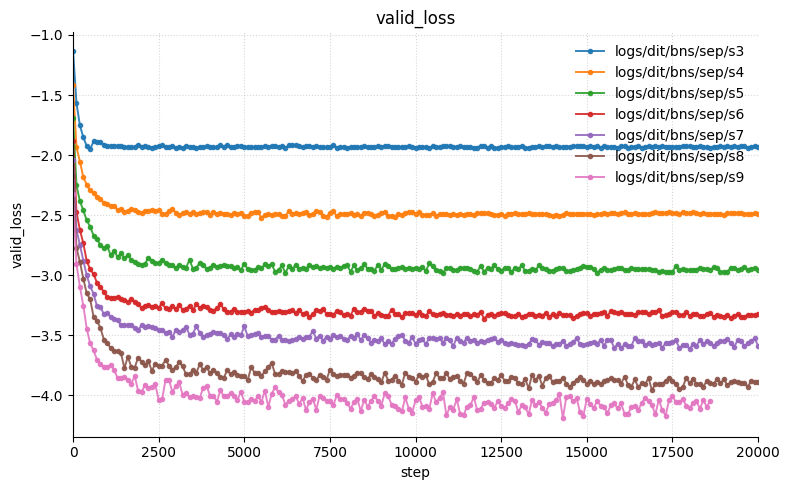

In [3]:
# TensorBoard scalars -> Matplotlib (explicit dirs, tags required; no UI, no error handling)
from tensorboard.backend.event_processing import event_accumulator as ea
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

RUN_DIRS = ["logs/dit/bns/sep/s3",
            "logs/dit/bns/sep/s4",
            "logs/dit/bns/sep/s5",
            "logs/dit/bns/sep/s6",
            "logs/dit/bns/sep/s7",
            "logs/dit/bns/sep/s8",
            "logs/dit/bns/sep/s9",
            ]
TAGS = ['valid_loss', 'mse_loss']

# load
metrics = {}  # {tag: {run: (steps, values)}}
for r in RUN_DIRS:
    if not os.path.exists(r):
        continue
    acc = ea.EventAccumulator(r, size_guidance={ea.SCALARS:0}); acc.Reload()
    for t in acc.Tags()["scalars"]:
        ev = acc.Scalars(t)
        s = np.array([e.step for e in ev]); v = np.array([e.value for e in ev])
        i = np.argsort(s, kind="stable"); s, v = s[i], v[i]      # sort by step
        u, k = np.unique(s, return_index=True); s, v = u, v[k]   # dedup steps
        (metrics.setdefault(t, {}))[r] = (s, v)

if not TAGS:
    print("Available tags:"); 
    for t in sorted(metrics.keys()): print(" •", t)
else:
    for t in TAGS:
        if t not in metrics: continue
        fig, ax = plt.subplots(figsize=(8,5))
        for r,(s,v) in metrics[t].items():
            ax.plot(s, v, '-o', markersize=3, linewidth=1.4, alpha=0.9, label=Path(r))
        ax.set_title(t)
        ax.set_xlabel("step"); ax.set_ylabel(t.split("/")[-1])
        ax.grid(True, linestyle=":", alpha=0.5); ax.margins(x=0.02)
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
        ax.legend(frameon=False)
        plt.xlim([0, 20*1000]); plt.tight_layout(); plt.show()


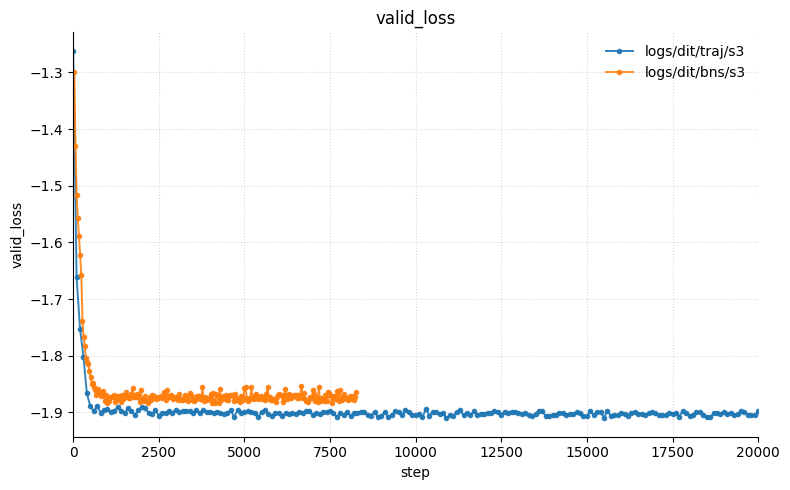

In [4]:
# TensorBoard scalars -> Matplotlib (explicit dirs, tags required; no UI, no error handling)
from tensorboard.backend.event_processing import event_accumulator as ea
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

RUN_DIRS = ["logs/dit/traj/s3",
            "logs/dit/bns/s3"
            ]
TAGS = ['valid_loss']

# load
metrics = {}  # {tag: {run: (steps, values)}}
for r in RUN_DIRS:
    if not os.path.exists(r):
        continue
    acc = ea.EventAccumulator(r, size_guidance={ea.SCALARS:0}); acc.Reload()
    for t in acc.Tags()["scalars"]:
        ev = acc.Scalars(t)
        s = np.array([e.step for e in ev]); v = np.array([e.value for e in ev])
        i = np.argsort(s, kind="stable"); s, v = s[i], v[i]      # sort by step
        u, k = np.unique(s, return_index=True); s, v = u, v[k]   # dedup steps
        (metrics.setdefault(t, {}))[r] = (s, v)

if not TAGS:
    print("Available tags:"); 
    for t in sorted(metrics.keys()): print(" •", t)
else:
    for t in TAGS:
        if t not in metrics: continue
        fig, ax = plt.subplots(figsize=(8,5))
        for r,(s,v) in metrics[t].items():
            ax.plot(s, v, '-o', markersize=3, linewidth=1.4, alpha=0.9, label=Path(r))
        ax.set_title(t)
        ax.set_xlabel("step"); ax.set_ylabel(t.split("/")[-1])
        ax.grid(True, linestyle=":", alpha=0.5); ax.margins(x=0.02)
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
        if len(metrics[t])>1: ax.legend(frameon=False)
        plt.xlim([0, 20*1000]); plt.tight_layout(); plt.show()


2025-09-06 02:21:30.322074: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


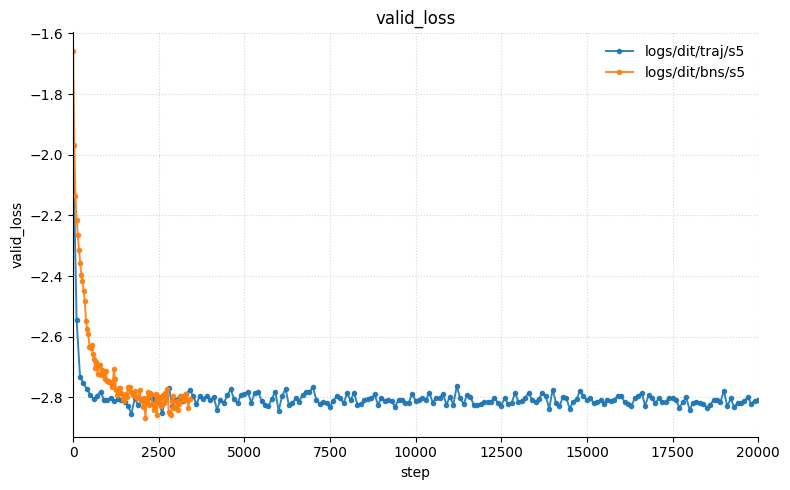

In [3]:
# TensorBoard scalars -> Matplotlib (explicit dirs, tags required; no UI, no error handling)
from tensorboard.backend.event_processing import event_accumulator as ea
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

RUN_DIRS = ["logs/dit/traj/s5",
            "logs/dit/bns/s5"
            ]
TAGS = ['valid_loss']

# load
metrics = {}  # {tag: {run: (steps, values)}}
for r in RUN_DIRS:
    if not os.path.exists(r):
        continue
    acc = ea.EventAccumulator(r, size_guidance={ea.SCALARS:0}); acc.Reload()
    for t in acc.Tags()["scalars"]:
        ev = acc.Scalars(t)
        s = np.array([e.step for e in ev]); v = np.array([e.value for e in ev])
        i = np.argsort(s, kind="stable"); s, v = s[i], v[i]      # sort by step
        u, k = np.unique(s, return_index=True); s, v = u, v[k]   # dedup steps
        (metrics.setdefault(t, {}))[r] = (s, v)

if not TAGS:
    print("Available tags:"); 
    for t in sorted(metrics.keys()): print(" •", t)
else:
    for t in TAGS:
        if t not in metrics: continue
        fig, ax = plt.subplots(figsize=(8,5))
        for r,(s,v) in metrics[t].items():
            ax.plot(s, v, '-o', markersize=3, linewidth=1.4, alpha=0.9, label=Path(r))
        ax.set_title(t)
        ax.set_xlabel("step"); ax.set_ylabel(t.split("/")[-1])
        ax.grid(True, linestyle=":", alpha=0.5); ax.margins(x=0.02)
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
        if len(metrics[t])>1: ax.legend(frameon=False)
        plt.xlim([0, 20*1000]); plt.tight_layout(); plt.show()


In [ ]:
# TensorBoard scalars -> Matplotlib (explicit dirs, tags required; no UI, no error handling)
from tensorboard.backend.event_processing import event_accumulator as ea
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

RUN_DIRS = ["logs/dit/traj/s7",
            "logs/dit/bns/s7"
            ]
TAGS = ['valid_loss']

# load
metrics = {}  # {tag: {run: (steps, values)}}
for r in RUN_DIRS:
    if not os.path.exists(r):
        continue
    acc = ea.EventAccumulator(r, size_guidance={ea.SCALARS:0}); acc.Reload()
    for t in acc.Tags()["scalars"]:
        ev = acc.Scalars(t)
        s = np.array([e.step for e in ev]); v = np.array([e.value for e in ev])
        i = np.argsort(s, kind="stable"); s, v = s[i], v[i]      # sort by step
        u, k = np.unique(s, return_index=True); s, v = u, v[k]   # dedup steps
        (metrics.setdefault(t, {}))[r] = (s, v)

if not TAGS:
    print("Available tags:"); 
    for t in sorted(metrics.keys()): print(" •", t)
else:
    for t in TAGS:
        if t not in metrics: continue
        fig, ax = plt.subplots(figsize=(8,5))
        for r,(s,v) in metrics[t].items():
            ax.plot(s, v, '-o', markersize=3, linewidth=1.4, alpha=0.9, label=Path(r))
        ax.set_title(t)
        ax.set_xlabel("step"); ax.set_ylabel(t.split("/")[-1])
        ax.grid(True, linestyle=":", alpha=0.5); ax.margins(x=0.02)
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
        if len(metrics[t])>1: ax.legend(frameon=False)
        plt.ylim([-3.6, -3.0]); plt.xlim([0, 20*1000]); plt.tight_layout(); plt.show()


NameError: name 'os' is not defined

In [3]:
# TensorBoard scalars -> Matplotlib (explicit dirs, tags required; no UI, no error handling)
from tensorboard.backend.event_processing import event_accumulator as ea
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

RUN_DIRS = ["logs/dit/traj/s9",
            "logs/dit/bns/s9"
            ]
TAGS = ['valid_loss']

# load
metrics = {}  # {tag: {run: (steps, values)}}
for r in RUN_DIRS:
    acc = ea.EventAccumulator(r, size_guidance={ea.SCALARS:0}); acc.Reload()
    for t in acc.Tags()["scalars"]:
        ev = acc.Scalars(t)
        s = np.array([e.step for e in ev]); v = np.array([e.value for e in ev])
        i = np.argsort(s, kind="stable"); s, v = s[i], v[i]      # sort by step
        u, k = np.unique(s, return_index=True); s, v = u, v[k]   # dedup steps
        (metrics.setdefault(t, {}))[r] = (s, v)

if not TAGS:
    print("Available tags:"); 
    for t in sorted(metrics.keys()): print(" •", t)
else:
    for t in TAGS:
        if t not in metrics: continue
        fig, ax = plt.subplots(figsize=(8,5))
        for r,(s,v) in metrics[t].items():
            ax.plot(s, v, '-o', markersize=3, linewidth=1.4, alpha=0.9, label=Path(r))
        ax.set_title(t)
        ax.set_xlabel("step"); ax.set_ylabel(t.split("/")[-1])
        ax.grid(True, linestyle=":", alpha=0.5); ax.margins(x=0.02)
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
        if len(metrics[t])>1: ax.legend(frameon=False)
        plt.ylim([-4.5, -3.5]); plt.xlim([0, 20*1000]); plt.tight_layout(); plt.show()


2025-09-05 19:47:01.940692: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


DirectoryDeletedError: Directory logs/dit/traj/s9 has been permanently deleted